In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn
import torch.optim as optim
from torch.amp import GradScaler, autocast

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)


class VATSA_VisualEncoder(nn.Module):
    def __init__(self, embedding_dim=512, num_classes=10, freeze_backbone=True):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = efficientnet_b0(weights=weights)
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.projection = nn.Linear(num_features, embedding_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),                          # ✅ dropout added
            nn.Linear(embedding_dim, num_classes)
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)
        embedding = self.projection(features)
        logits = self.classifier(embedding)
        return logits, embedding


device = "cuda" if torch.cuda.is_available() else "cpu"

# ✅ Load previous checkpoint and continue training
checkpoint = torch.load("vatsa_visual_encoder_cifar10.pth", map_location=device)
model = VATSA_VisualEncoder(embedding_dim=512, num_classes=10, freeze_backbone=True).to(device)
model.load_state_dict(checkpoint['model_state'], strict=False)  # strict=False handles classifier shape change

# ✅ Unfreeze last few backbone layers for fine-tuning
for param in model.backbone.features[4:].parameters():
    param.requires_grad = True

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

best_acc = 0.0

for epoch in range(40): #higher epochs for fine-tuning
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            logits, _ = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits, _ = model(images)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

    acc = correct / total * 100

    # ✅ Save best model only
    if acc > best_acc:
        best_acc = acc
        torch.save({
            'model_state': model.state_dict(),
            'embedding_dim': 512
        }, "vatsa_visual_encoder_cifar10_deeper_unfreeze.pth")
        print(f"Epoch {epoch+1}/20 - Loss: {avg_loss:.4f} - Test Acc: {acc:.2f}% ✅ Best saved")
    else:
        print(f"Epoch {epoch+1}/20 - Loss: {avg_loss:.4f} - Test Acc: {acc:.2f}%")

print(f"\nBest Accuracy: {best_acc:.2f}%")

c:\Users\vinay\OneDrive\Desktop\VATSA\VATSA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


OutOfMemoryError: CUDA out of memory. Tried to allocate 66.00 MiB. GPU 0 has a total capacity of 8.00 GiB of which 5.03 GiB is free. Of the allocated memory 1.82 GiB is allocated by PyTorch, and 65.04 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

: 

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

class VATSA_VisualEncoder(nn.Module):
    def __init__(self, embedding_dim=512, num_classes=10, freeze_backbone=True):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = efficientnet_b0(weights=weights)
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.projection = nn.Linear(num_features, embedding_dim)
        self.classifier = nn.Sequential(          # ← fix: match training code
            nn.Dropout(0.3),
            nn.Linear(embedding_dim, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        embedding = self.projection(features)
        logits = self.classifier(embedding)
        return logits, embedding

device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint = torch.load("vatsa_visual_encoder_cifar10_deeper_unfreeze.pth", map_location=device)
model = VATSA_VisualEncoder(embedding_dim=512, num_classes=10).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = model(images)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {correct/total*100:.2f}%")

c:\Users\vinay\OneDrive\Desktop\VATSA\VATSA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Test Accuracy: 96.31%


In [4]:
import numpy as np
from tqdm import tqdm

print("\nExtracting embeddings...")

all_embeddings = []
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)

        logits, embeddings = model(images)

        preds = logits.argmax(1).cpu().numpy()

        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())
        all_preds.append(preds)

all_embeddings = np.vstack(all_embeddings)
all_labels = np.hstack(all_labels)
all_preds = np.hstack(all_preds)

print("Embeddings shape:", all_embeddings.shape)


Extracting embeddings...


100%|██████████| 40/40 [00:21<00:00,  1.83it/s]

Embeddings shape: (10000, 512)


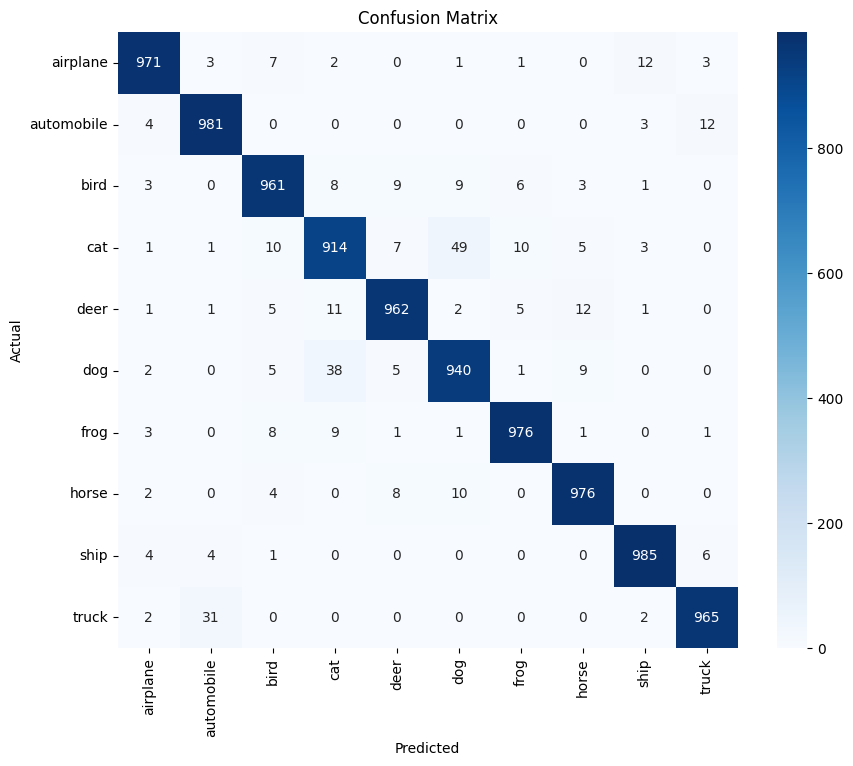

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = test_set.classes

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [6]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy\n")

for i, acc in enumerate(per_class_accuracy):
    print(f"{class_names[i]:10s}: {acc*100:.2f}%")


Per-Class Accuracy

airplane  : 97.10%
automobile: 98.10%
bird      : 96.10%
cat       : 91.40%
deer      : 96.20%
dog       : 94.00%
frog      : 97.60%
horse     : 97.60%
ship      : 98.50%
truck     : 96.50%


In [7]:
embedding_norms = np.linalg.norm(all_embeddings, axis=1)

print("\nEmbedding Statistics")
print("---------------------")

print("Mean norm:", np.mean(embedding_norms))
print("Std norm :", np.std(embedding_norms))
print("Min norm :", np.min(embedding_norms))
print("Max norm :", np.max(embedding_norms))

mean_embedding = np.mean(all_embeddings, axis=0)

print("\nEmbedding Vector Stats")
print("Mean value:", np.mean(mean_embedding))
print("Std value :", np.std(mean_embedding))


Embedding Statistics
---------------------
Mean norm: 32.720875
Std norm : 6.518829
Min norm : 11.320934
Max norm : 59.652306

Embedding Vector Stats
Mean value: 0.0011413372
Std value : 0.22084892



Running t-SNE...


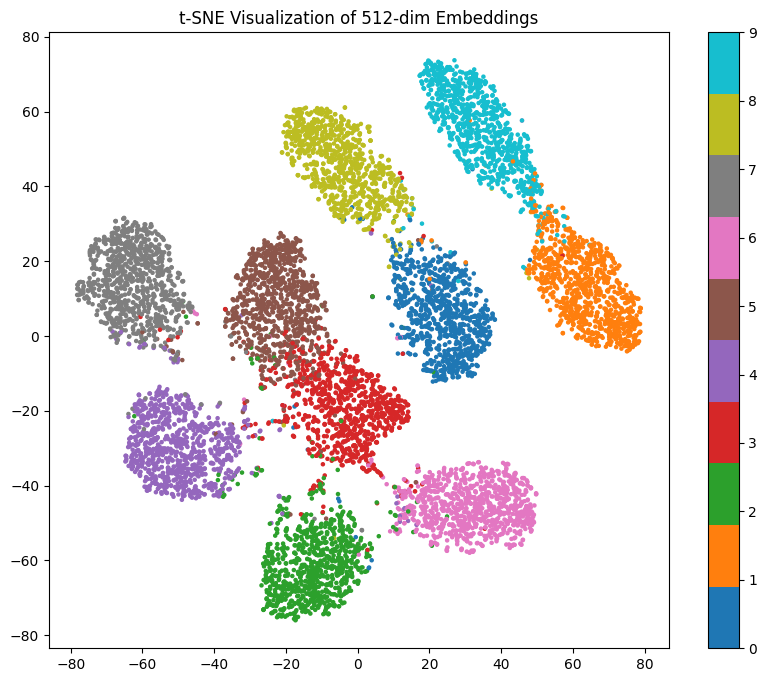

In [11]:
from sklearn.manifold import TSNE

print("\nRunning t-SNE...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,   # ✅ FIX (was n_iter)
    random_state=42
)

tsne_result = tsne.fit_transform(all_embeddings)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=all_labels,
    cmap="tab10",
    s=5
)

plt.colorbar(scatter)

plt.title("t-SNE Visualization of 512-dim Embeddings")

plt.show()


Running UMAP...


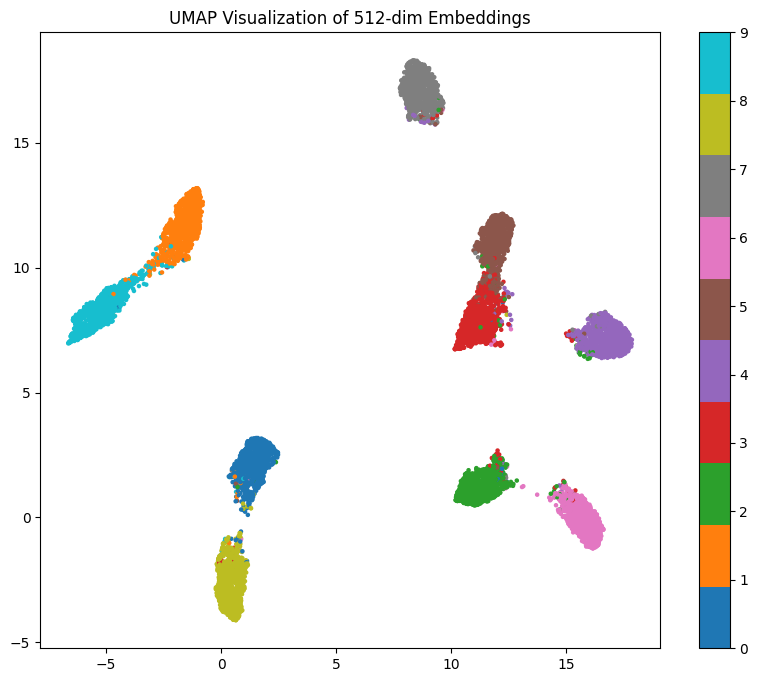

In [12]:
import umap

print("\nRunning UMAP...")

umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean"
)

umap_result = umap_reducer.fit_transform(all_embeddings)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    umap_result[:,0],
    umap_result[:,1],
    c=all_labels,
    cmap="tab10",
    s=5
)

plt.colorbar(scatter)

plt.title("UMAP Visualization of 512-dim Embeddings")

plt.show()

In [13]:
print("\nComputing class centers...")

class_centers = []

for i in range(len(class_names)):
    class_embeddings = all_embeddings[all_labels == i]
    center = class_embeddings.mean(axis=0)
    class_centers.append(center)

class_centers = np.array(class_centers)

print("Class centers shape:", class_centers.shape)


Computing class centers...
Class centers shape: (10, 512)


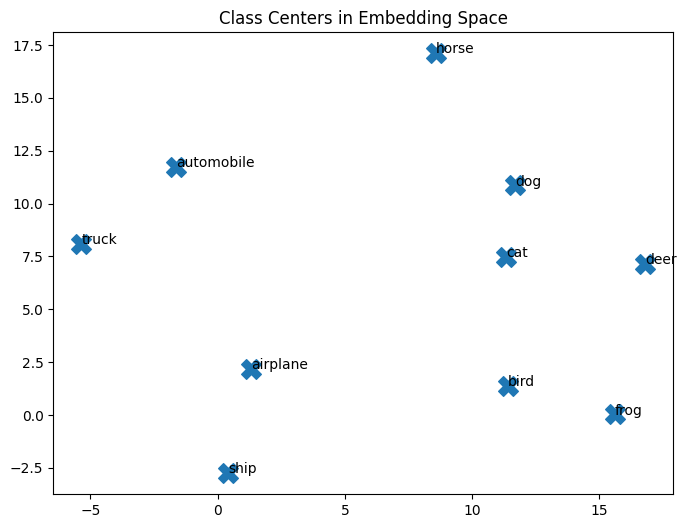

In [14]:
center_umap = umap_reducer.transform(class_centers)

plt.figure(figsize=(8,6))

plt.scatter(
    center_umap[:,0],
    center_umap[:,1],
    s=200,
    marker="X"
)

for i, txt in enumerate(class_names):
    plt.text(center_umap[i,0], center_umap[i,1], txt)

plt.title("Class Centers in Embedding Space")

plt.show()